# **Algorithm Design/Planning**

We choose to adopt a classification approach to model diabetes outcome. The primary reasoning for this approach is that the target variable represents discrete categories: presence and stage of diabetes. Because we aim to assign each individual a specific label, classification models are more appropriate than other machine learning approaches. Clustering was not selected because it is used to discover hidden groupings in data without predefined labels. In this case, the dataset already contains labeled outcomes, and the objective is to predict these labels. Therefore, a supervised learning method is more suitable. Regression was also considered but not ultimately chosen, as diabetes stage is not a continuous numerical value.

We chose to test multiple classification models: Logistic Regression, Gradient Boosting, Decision Tree, Random Forest, and KNN.

Logistic Regression, Decision Tree, Random Forest, and KNN were all taught in class, and chosen for their various levels of complexity. We also chose to include Gradient Boosting, which builds trees through sequential ML models, as we wanted to test if boosting or bagging (ensemble/Random Forest) would result in better predictions.

We focus on Recall during evaluation as we want to minimize false negatives as much as possible. For medical diagnosis, it is safer to get a false positive as failing to diagnose sick patients has much larger consequences; further testing can always be done to verify the results.

[Google Developers Recall Definition](https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, silhouette_score

import matplotlib.pyplot as plt
import matplotlib
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize

from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

import ast
pd.set_option('display.max_columns', None)
from scipy.spatial.distance import cdist

import matplotlib.pyplot as plt
import seaborn as sns
import warnings # To suppress some warnings
import plotly.graph_objects as go
import plotly.express as px

# Suppress the specific FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

# Add the classifiers to the imports here:
# ANSWER STARTING HERE

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.ensemble import GradientBoostingClassifier

import hashlib
from sklearn.preprocessing import MinMaxScaler

In [ ]:
df = pd.read_csv("diabetes_dataset.csv")

df = df[df['ldl_cholesterol'] > 50]
df = df[df['insulin_level'] > 2]

X = df[['ldl_cholesterol','insulin_level','hba1c','waist_to_hip_ratio']]
Y = df[['diabetes_stage']]

Y['diabetes_num'] = Y['diabetes_stage'].apply(lambda x: 0 if x == 'No Diabetes' else (1 if x == 'Pre-Diabetes' else (2 if x == 'Type 1' else (3 if x == 'Type 2' else (4 if x == 'Gestational' else -1)))))

# no missing diabetes stage labels
print(Y[Y['diabetes_num'] == -1].sum())



diabetes_stage     
diabetes_num      0
dtype: object


# **Encoding**
Before fitting our models we had to make sure that our data could be supported by these models, namely, if our data was properly cleaned and formatted to be fitted with the models. In our previous section, we already concluded that there are no missing data entries and we fixed any zero offset errors (as we saw in the cholesterol and insulin level entries). In addition to that, every single one of our models (Logistic Regression, Decision Tree, Random Forest, and KNN) requires numerical input rather than categorical. Because of this, we have to encode our categories to numerical values. There are several ways to do this but because we are simply “renaming” our categories, we can use Ordinal Encoding which encodes our categories in increasing integral values: No Diabetes = 0, Pre Diabetes = 1, Type 1 = 2, Type 2 = 3, Gestational = 4.

No Diabetes Count:  6198
Pre Diabetes Count:  26013
Type 1 Diabetes Count:  90
Type 2 Diabetes Count:  50520
Gestational Diabetes Count:  217


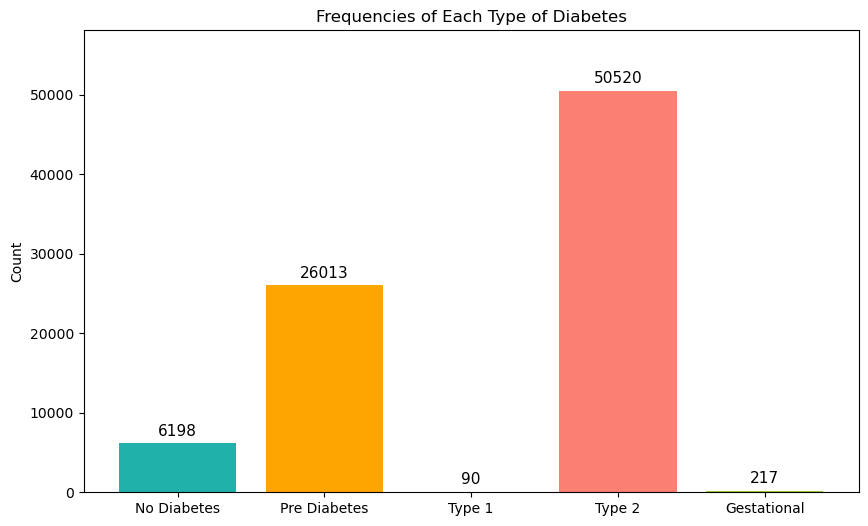

In [ ]:
No_diabetes_freq = Y[Y['diabetes_num'] == 0]['diabetes_num'].count()
Pre_diabetes_freq = Y[Y['diabetes_num'] == 1]['diabetes_num'].count()
Type1_diabetes_freq = Y[Y['diabetes_num'] == 2]['diabetes_num'].count()
Type2_diabetes_freq = Y[Y['diabetes_num'] == 3]['diabetes_num'].count()
Gestational_diabetes_freq = Y[Y['diabetes_num'] == 4]['diabetes_num'].count()


print("No Diabetes Count: ", No_diabetes_freq);
print("Pre Diabetes Count: ", Pre_diabetes_freq);
print("Type 1 Diabetes Count: ", Type1_diabetes_freq);
print("Type 2 Diabetes Count: ", Type2_diabetes_freq);
print("Gestational Diabetes Count: ", Gestational_diabetes_freq);


Freq_list = [No_diabetes_freq, Pre_diabetes_freq, Type1_diabetes_freq, Type2_diabetes_freq, Gestational_diabetes_freq]
dtype = ['No Diabetes', 'Pre Diabetes', 'Type 1', 'Type 2', 'Gestational']
bar_colors = ['lightseagreen', 'orange', 'deepskyblue', 'salmon', 'yellowgreen']


fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(dtype, Freq_list, color=bar_colors)
ax.bar_label(bars, padding=3, fontsize=11)


ax.set_ylim(0, max(Freq_list) * 1.15)
ax.set_ylabel('Count')
ax.set_title('Frequencies of Each Type of Diabetes')


plt.show()

In [ ]:
seed = 67
test_size = 0.2
X_train, X_test, y_train, y_test = train_test_split(X, Y['diabetes_num'], test_size=test_size, random_state=seed, stratify=Y['diabetes_num'])

# **Accounting for Imbalanced Data**
Medical data is often imbalanced, as they reflect real world distributions, i.e. rarity of disease, voluntary bias. As can be seen in the graph, in the case of our dataset “Type 1” Diabetes and “Gestational” Diabetes are severely under represented.

We do two things to combat this imbalance:
1. We stratify during the train-test splitting
2. We calculate class weights

Class weights penalize misclassification on minority classes, forcing equal attention even if one class has lower frequency. Due to the fact that a few of our models do not have a class_weight parameter, we chose to calculate sample_weight instead. sample_weight is a reformatted version of class_weight. Instead of a list of weights corresponding to each class, sample_weight formats these weights to correspond to y_train row’s class label. sample_weight is then applied as a parameter inside of the fit function.

**Additional Resources:** 

[Official Sklearn compute_sample_weight Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_sample_weight.html) 

[Difference between sample weight and class weight](https://stackoverflow.com/questions/32492550/what-is-the-difference-between-sample-weight-and-class-weight-options-in-scikit)

[How to handle imbalanced datasets - GeeksForGeeks](https://www.geeksforgeeks.org/machine-learning/handling-imbalanced-data-for-classification/)

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight

# 'y_train' represents your target labels
classes = np.unique(y_train)

# Calculate weights based on the 'balanced' heuristic
# We compute sample weight instead of class weight because some of our models do not have a class_weight parameter
weights = compute_sample_weight(class_weight='balanced', y=y_train)

In [ ]:
# Scale the X values (and not Y, as Y are labels and thus do not need scaling)
scaler = StandardScaler().fit(X)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(random_state=seed,max_iter=1000),
    'Gradient Boosting' : GradientBoostingClassifier(random_state=seed),
    'Decision Tree'    : DecisionTreeClassifier(random_state=seed),
    'Random Forest'    : RandomForestClassifier(random_state=seed),
    'KNN'              : KNeighborsClassifier()
}

In [ ]:
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=seed)

for model_name, model in models.items():
    np.random.seed(42)
    print(f"Model: {model_name}")

    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=skf)
    print(f"Cross-validated Accuracy: {cv_scores.mean()} (+/- {cv_scores.std()})")

Model: Logistic Regression
Cross-validated Accuracy: 0.7936474484419691 (+/- 0.002111026888245732)
Model: Gradient Boosting
Cross-validated Accuracy: 0.8588589492699082 (+/- 0.0007956992495199561)
Model: Decision Tree
Cross-validated Accuracy: 0.797154899894626 (+/- 0.003138199931227051)
Model: Random Forest
Cross-validated Accuracy: 0.8522655426765017 (+/- 0.0006688201081295536)
Model: KNN
Cross-validated Accuracy: 0.8261779316573836 (+/- 0.001532644213302461)


# **Statified K-Fold Analysis**
We conducted Stratified K-Fold analysis cross-validation on all models in order to test their accuracy. The test data was previously separated into 80% training - 20% testing data, and then scaled based on total X data.

After Stratified K-Fold cross-validation, Gradient Boosting had the best mean cross validation score (and smaller variance amongst top 2 scores). Random Forest was a very close second, with a mean score that’s only 0.007 lower than Gradient Boosting’s mean score.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer

updated_param_list = {}

for model_name, model in models.items():
    param_grid = {}
    if model_name == 'Logistic Regression':
        param_grid = {'max_iter': [1000, 2000, 3000],
                      'C': [0.01, 0.1, 1, 10]}
    elif model_name == 'Gradient Boosting':
        param_grid = {'n_estimators': [100, 200],
                    'learning_rate': [0.01, 0.1, 0.2],
                    'max_depth': [3, 5, 7]}
    elif model_name == 'Decision Tree':
        param_grid = {'max_depth': [None, 10, 20, 30],
                    'min_samples_split': [2, 5, 10]}
    elif model_name == 'Random Forest':
        param_grid = {'n_estimators': [100, 200],
                    'max_depth': [None, 10, 20, 30],
                    'min_samples_split': [2, 5, 10]}
    else:
        continue

    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='recall_macro', n_jobs=-1)
    grid_search.fit(X_train, y_train, sample_weight=weights)
    models[model_name] = grid_search.best_estimator_

    updated_param_list[model_name] = grid_search.best_params_

for model_name,params in updated_param_list.items():
    print(model_name + ": ")
    print(params)


/opt/miniconda3/envs/sklearn-env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/miniconda3/envs/sklearn-env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable

Logistic Regression: 
{'C': 1, 'max_iter': 1000}
Gradient Boosting: 
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
Decision Tree: 
{'max_depth': 10, 'min_samples_split': 10}
Random Forest: 
{'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}


Due to how close the top two cross validation accuracy scores are, we decided to fine-tune . For completeness, and because all models had relatively high scores, we decided to fine-tune the remaining models as well. In order to find the best hyperparameters, we conducted a Grid Search. Grid Search iterates through a given list of increasing values for each parameter, conducting K-fold cross-validation scoring until it finds the best hyperparameters to maximize ‘recall_macro’ - the unweighted average recall. We then replace the initial hyperparameters with their best hyperparameters.
The list of values chosen were based on standard/default values for those parameters, then decreasing and increasing by a proportional amount to the default - primarily increasing or decreasing by ½*default value.

[GridSearchCV Official Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)

As explained earlier, since we are working with medical data to predict a diagnosis, we will be evaluating the performance of (unweighted average) recall. Just to reiterate, we prioritize maximizing recall as medical diagnosis focused on capturing as many true positives as possible.

Using these updated models, we conducted the final predictions below:


In [ ]:
# Train each model using the training data
for model_name, model in models.items():
    # Set random seed for reproducibility
    np.random.seed(seed)

    if model_name == "KNN":
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train_scaled, y_train, sample_weight=weights)


# Evaluate the performance of each model
for model_name, model in models.items():
    np.random.seed(seed)

    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test,y_pred)
    print(f"Accuracy of {model_name}: {accuracy:.3f}") # Your accuracy table header here
    print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Pre-Diabetes', 'Type 1', 'Type 2', 'Gestational']))

Accuracy of Logistic Regression: 0.598
              precision    recall  f1-score   support

 No Diabetes       0.53      0.83      0.65      1240
Pre-Diabetes       0.74      0.47      0.57      5203
      Type 1       0.00      0.06      0.00        18
      Type 2       0.98      0.64      0.77     10104
 Gestational       0.00      0.23      0.01        43

    accuracy                           0.60     16608
   macro avg       0.45      0.44      0.40     16608
weighted avg       0.86      0.60      0.70     16608

Accuracy of Gradient Boosting: 0.831
              precision    recall  f1-score   support

 No Diabetes       0.50      1.00      0.66      1240
Pre-Diabetes       0.80      0.83      0.81      5203
      Type 1       0.00      0.00      0.00        18
      Type 2       1.00      0.82      0.90     10104
 Gestational       0.00      0.02      0.00        43

    accuracy                           0.83     16608
   macro avg       0.46      0.53      0.48     16608
w

/opt/miniconda3/envs/sklearn-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/sklearn-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/sklearn-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

# **Result**
The primary conclusion of our model analysis is that the best model after fine-tuning (based on overall accuracy) is Random Forest. Even so, it is important to note that all of the models we used were unable to accurately predict Type 1 or Gestational diabetes. We believe that this is due to the massive disparity in sample sizes between diabetes stages. For reference, there are approximately 250 times more samples of the Pre-Diabetes stage than the Type 1 stage, and there are approximately 500 times more samples of the Type 2 stage than the Type 1 stage.
We tried to account for this imbalance with stratification and sample weights since we could not use other methods like extrapolating or gathering more data. Even with this method, the recall for both Type 1 and Gestational diabetes was still extremely low.

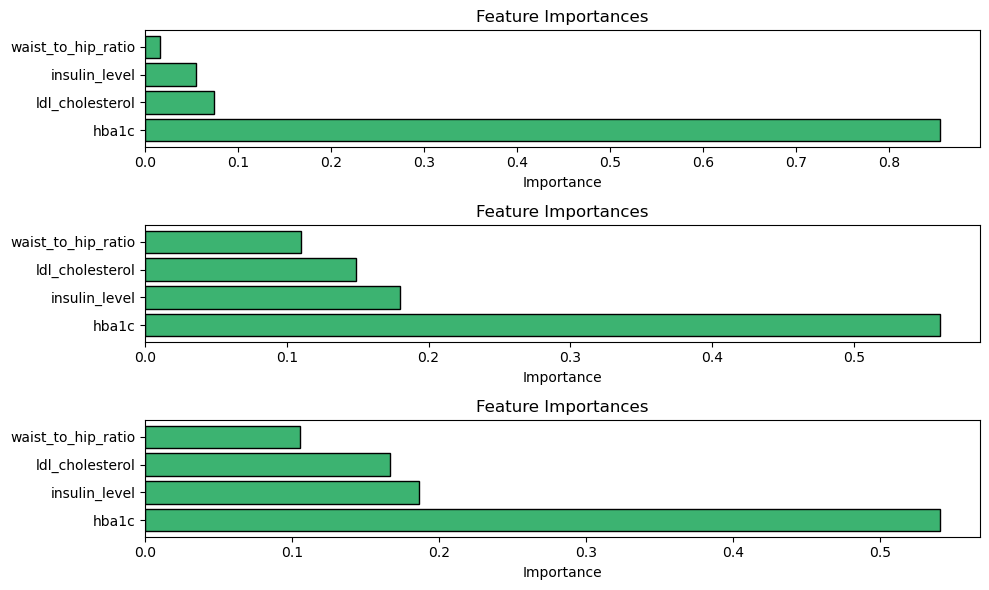

In [ ]:
# Extract the feature importances from the most accurate model
importances1 = models['Gradient Boosting'].feature_importances_
importances2 = models['Decision Tree'].feature_importances_
importances3 = models['Random Forest'].feature_importances_


# Creating a DataFrame to display feature importances
feature_importance_df = pd.DataFrame({0:importances1,1:importances2,2:importances3},index=X.columns).sort_values(by=[0], ascending=False)
# Displaying feature importances
# print("Feature Importances:")
# print(feature_importance_df[:4])
# print(X.columns)

fig, axes = plt.subplots(3, 1, figsize=(10, 6))
axes = axes.flatten()  # Make it easier to index
feature_list = [importances1, importances2, importances3]

for i, feature in enumerate(feature_list) :
    ax = axes[i]

    feature_importance = pd.Series(feature, index = X.columns).sort_values(ascending=False)
    ax.barh(feature_importance .index, feature_importance.values, color='mediumseagreen', edgecolor='black')
    ax.set_xlabel('Importance')
    ax.set_title('Feature Importances')

plt.tight_layout()
plt.show()

When analysing the feature importances of our models, it was no surprise that HbA1c came out as the most important feature. Current medical professionals use HbA1c (Hemoglobin A1C) to help diagnose and manage pre-diabetes and diabetes since it measures average blood sugar levels over the past 2-3 months. As such, it would make sense that our model would primarily use this feature when making predictions.

**Additional Resources**:
[HbA1c - What it is and What it's used for](https://medlineplus.gov/lab-tests/hemoglobin-a1c-hba1c-test/) 

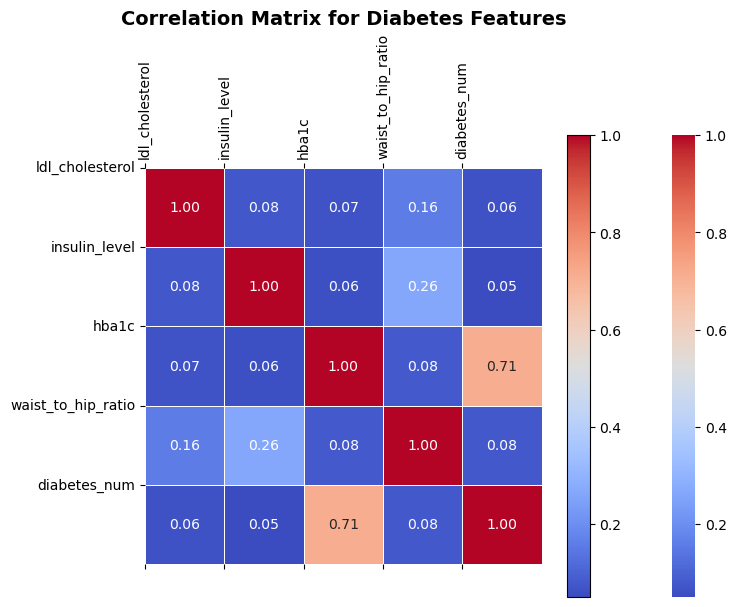

In [ ]:
total_pd = df[['ldl_cholesterol','insulin_level','hba1c','waist_to_hip_ratio']]
total_pd['diabetes_num'] = Y['diabetes_num']


corr = total_pd .corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title("Correlation Matrix for Diabetes Features", fontsize=14, fontweight='bold')
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
cax = ax.matshow(corr, cmap='coolwarm')
fig.colorbar(cax)


ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=90)
ax.set_yticks(range(len(corr.columns)), corr.columns)
plt.show()

Matching what the feature importances displayed, the heatmap shows that hba1c has the highest correlation with diabetes stage out of all the features. The main purpose of the heatmap is to visualize how the other features are correlated to each other.

# **Conclusion**

Through our exploratory data analysis, we found that several measurable health indicators are associated with diabetes stage and can be used to predict diabetes outcome with relatively high accuracy. In particular, LDL cholesterol level, insulin level, HbA1C, and waist-to-hip ratio demonstrated meaningful relationships with diabetes progression and therefore served as the primary features used in our predictive model. Our analysis also revealed broader trends (or lack thereof) among lifestyle and demographic factors such as smoking habits and diet quality, which helped us better understand the interactions between risk factors.

Our results showed that ensemble methods consistently outperformed other, simpler classification models. Gradient boosting initially achieved the highest cross-validation score, with random forest performing only slightly worse. After additional hyperparameter tuning, random forest ultimately achieved the strongest overall testing performance.  
One of the most significant challenges we faced with this project was severe class imbalance. Type 1 Diabetes and Gestational Diabetes were heavily underrepresented in the dataset, which limited the ability of all models to correctly classify these categories. Although stratified splitting and weighted training helped partially address this issue, the imbalance continues to be a major limitation of our model’s performance.

In conclusion, this project demonstrates the potential usefulness of machine learning techniques in medical prediction tasks. However, our results also highlight the limitations of these methods: when applied to rarer diseases or heavily imbalanced datasets, predictive performance will be reduced significantly due to the lack of sufficient data for minority classes.
